# Retrieve and Display Neural/Behavioral Data

The code below selects which experiment to retrieve. Data is organized by subject/region in each experiment, with each file corresponding to an electrode array.

Data is of shape

$
X \rightarrow (E, T, N) \\
y \rightarrow (E, T, 2)
$

Where:

* **E** — number of events  
* **T** — number of time points per event (sampled in ms)  
* **N** — number of units

User can specify the experiment and is then prompted to select the appropriate file.

Data must be stored in a "data" directory at the same level as the code. Within "data," each experiment is represented as its own directory. The files are included within those folders.

In [1]:
from imports import *
from const import *
from utils import *
from loaders import *

Load data (current only Jenkins data works)

In [2]:
EXPERIMENT = 'Jenkins' # or Chowdhury
filename = select_file(EXPERIMENT)
X, y, LFP, behavioral_markers, marker_labels = get_all_data_from_file(EXPERIMENT, filename)
print(f'Data is of shape: {X.shape[0]} time points, {X.shape[1]} trials, {X.shape[2]} neurons')

Processing array A with segments: ['A001', 'A002']
  A001: (7279306, 96)
  A002: (5661262, 96)
  Concatenated shape: (12940568, 96)
Processing array B with segments: ['B001', 'B002']
  B001: (7272833, 96)
  B002: (5729393, 96)
  Concatenated shape: (13002226, 96)

LFP concatenated shapes: [(96, 12940568), (96, 13002226)]
LFP timestamps: 12940568 samples (12940.57 seconds)
Trial time range: 171.97 to 12820.03 seconds

Trial window: -1.932 to 3.780 seconds relative to go_cue_time
Max duration: 5711 ms

Final data shapes:
  Spikes (X): (2327, 5711, 192)
  Hand velocity (y): (2327, 5711, 2)
  LFP: (2327, 5711, 192)
  Behavioral markers: (2327, 6)
Data is of shape: 2327 trials, 5711 time points, 192 neurons
Data is of shape: 2327 time points, 5711 trials, 192 neurons


For ease of re-running, we store the data in data/decoder for storing and retrieval.

In [3]:
pkl.dump(X, open('data/decoder/X', 'wb'))
pkl.dump(y, open('data/decoder/y', 'wb'))
pkl.dump(LFP, open('data/decoder/LFP', 'wb'))
pkl.dump(behavioral_markers, open('data/decoder/behavioral_markers', 'wb'))
pkl.dump(marker_labels, open('data/decoder/marker_labels', 'wb'))

In [2]:
X = pkl.load(open('data/decoder/X', 'rb'))
y = pkl.load(open('data/decoder/y', 'rb'))
LFP = pkl.load(open('data/decoder/LFP', 'rb'))
behavioral_markers = pkl.load(open('data/decoder/behavioral_markers', 'rb'))
marker_labels = pkl.load(open('data/decoder/marker_labels', 'rb'))

Any unit can be examined individually across spiking and LFP.

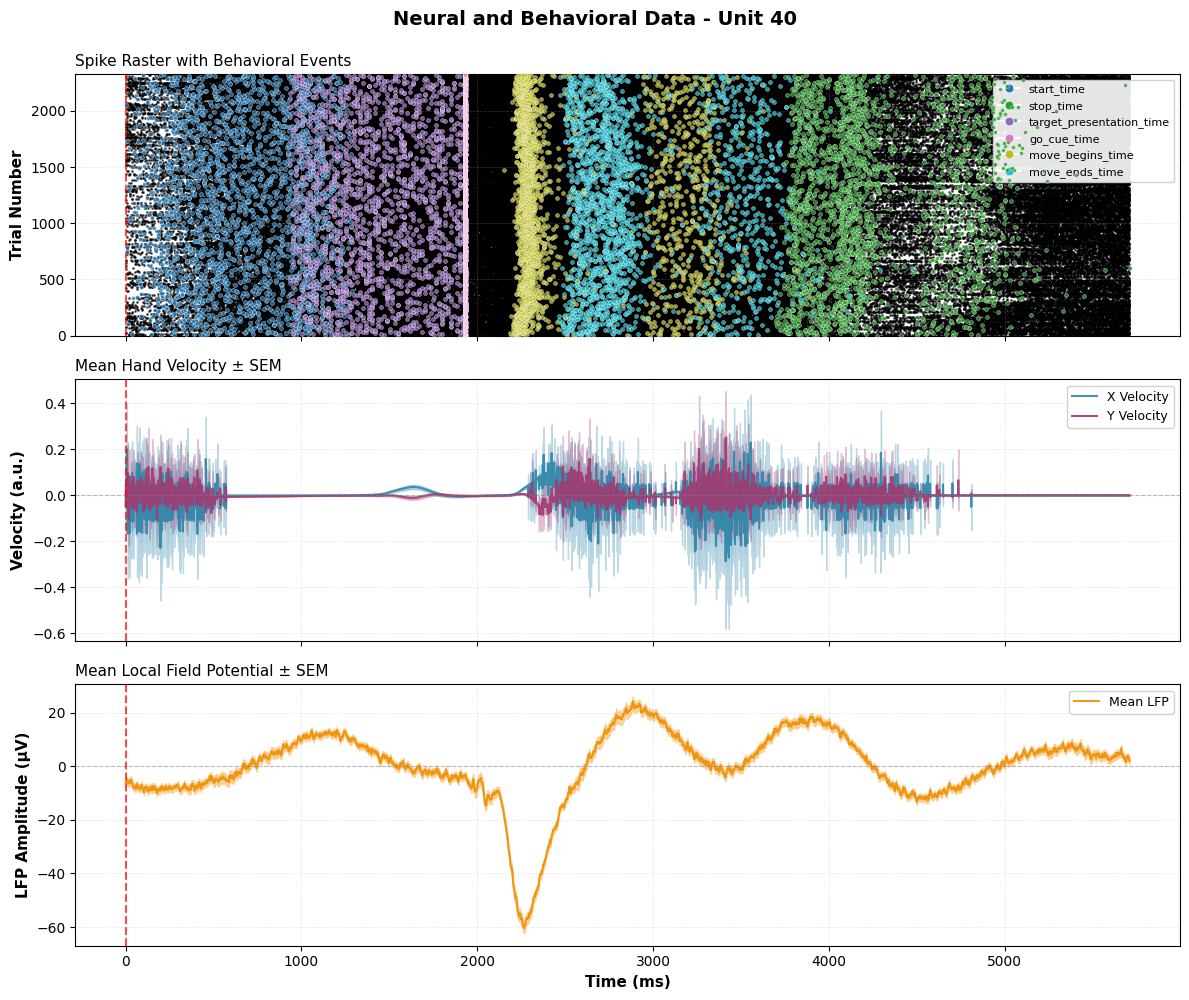

In [3]:
fig, axes = plot_neural_behavioral_data(X, y, LFP, behavioral_markers, marker_labels, neuron_idx=40)
plt.savefig('neural_behavioral_summary.png', dpi=300, bbox_inches='tight')
plt.show()

In [3]:
X_win, y_win, LFP_win, behavioral_markers_win, meta = bin_and_window_data(
        X, y, LFP, behavioral_markers,
        bin_size_ms=50,
        window_size_ms=5000,
        stride_ms=5000  # Non-overlapping windows. Sequential.
)
    
# Create decoder dataset.
# Inputs is a tuple of (spikes, LFP)
inputs, targets = create_decoder_dataset(X_win, y_win, LFP_win, meta)

Binning configuration:
  Original resolution: 1ms
  Target bin size: 50ms (50 original bins)
  Window size: 5000ms (100 target bins)
  Stride: 5000ms (100 target bins)
  Window overlap: 0ms

Binned data shapes:
  X_binned: (2327, 114, 192)
  y_binned: (2327, 114, 2)
  LFP_binned: (2327, 114, 192)

Windowed data shapes:
  X_windowed: (2327, 100, 192)
  y_windowed: (2327, 100, 2)
  LFP_windowed: (2327, 100, 192)
  Windows per trial: 1
  Total windows: 2327

Decoder dataset created:
  Spike inputs: (2327, 100, 192)
  LFP inputs: (2327, 100, 192)
  Targets: (2327, 2)


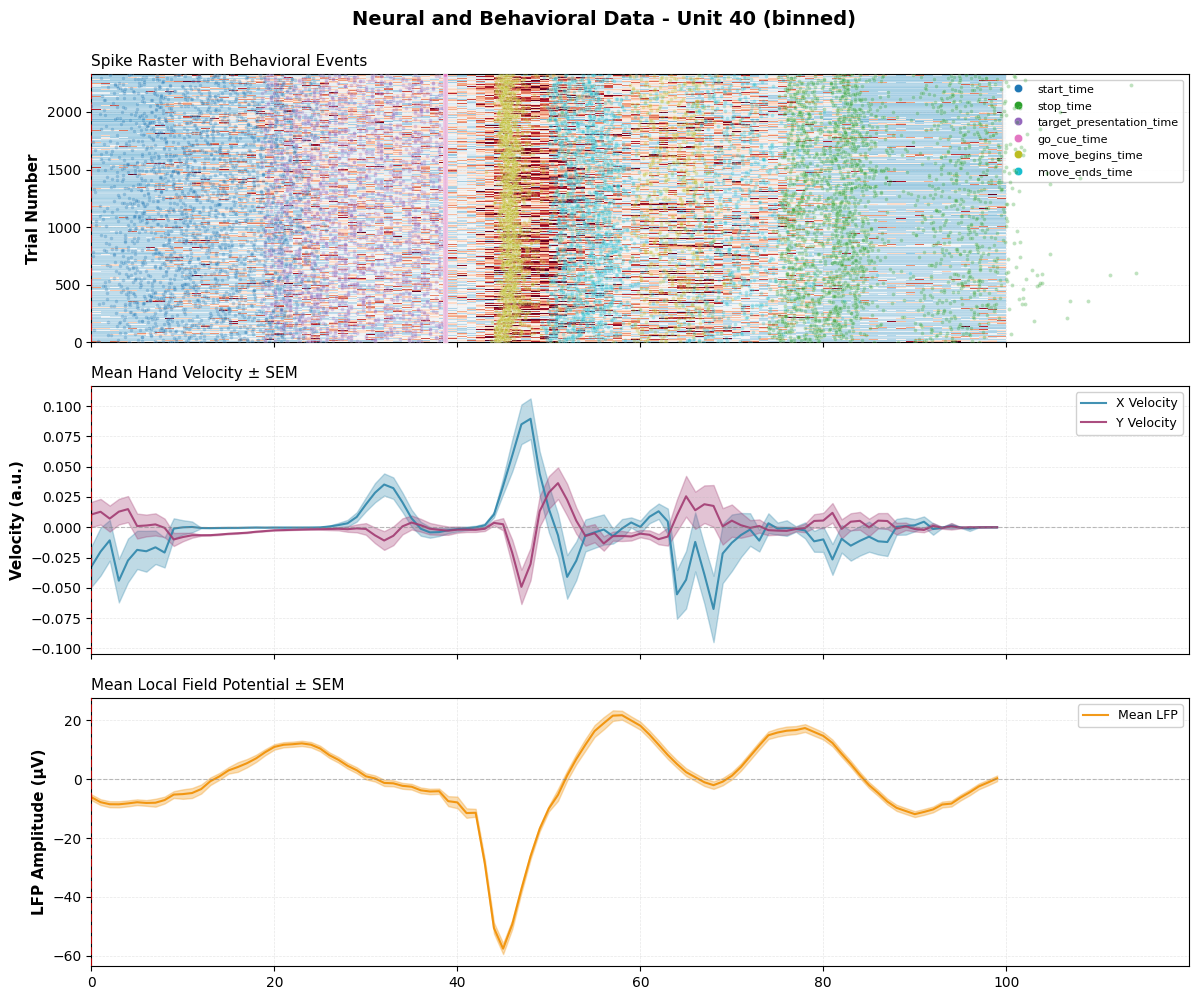

In [ ]:
fig, axes = plot_neural_behavioral_data(X_win, y_win, LFP_win, behavioral_markers_win, marker_labels, neuron_idx=40, binned=True)
plt.savefig('neural_behavioral_summary_binned.png', dpi=300, bbox_inches='tight')
plt.show()